# plot performance bar charts for paper!


In [1]:
#imports libraries
import re,os,sys,math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import glob
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_property(filename,prop):
    # print(filename)
    values_list=[]
    with open(filename,'r') as file:
        for line in file:
            if prop in line:
                val=float(line.split()[-1])
                values_list.append(val)
    if 'val' not in locals():
        last_val=math.nan
    else:
        last_val=values_list[-1]
    # print(values_list)
    return last_val
def get_datalist(root_folder,order,grids,metric,fix_bug=False):
    data_list=[]
    for counter,grid in enumerate(grids):
        metric_tmp=metric
        p_sb=get_property(os.path.join(root_folder,'log-SB'+order+grid+'.log'),metric_tmp)
        p_sb_abc=get_property(os.path.join(root_folder,'log-SB'+order+'-abc'+grid+'.log'),metric_tmp)
        p_tb=get_property(os.path.join(root_folder,'log-TB'+order+grid+'.log'),metric_tmp)
        p_tb_abc=get_property(os.path.join(root_folder,'log-TB'+order+'-abc'+grid+'.log'),metric_tmp)
        SB=[p_sb,p_sb_abc]
        TB=[p_tb,p_tb_abc]
        # print(SB);print(TB)
        if fix_bug==True and order=='_2nd' and metric=='GIGA FLOP / s':
            print('Bug fixwd. ATTENTION!!!!!!!!!')
            TB=[2*p_tb,2*p_tb_abc]
        else:
            TB=[p_tb,p_tb_abc]
        data_list.append([SB,TB])
    return data_list

In [3]:
title_shaheen='SB versus MWD modeling phase on the dual-socket 16-core Intel Haswell System @2.3GHz.'
title_kanary='SB versus MWD modeling phase on the dual-socket 128-core AMD Epyc Rome System @2.0GHz.'
title_milan='SB versus MWD modeling phase on the dual-socket 128-core AMD 7763 system.'
title_milanx='SB versus MWD modeling phase on the dual-socket 128-core AMD 7773X system.'
# grids=['_512_512_512','_1024_1024_512','_2048_2048_512','_2048_2048_1024','_2048_2048_2048']
grids=['_512_512_512','_1024_1024_512','_2048_2048_512','_2048_2048_1024']
grids=['_512_512_512','_1024_1024_512','_2048_2048_512']
metric='GIGA POINT / s'
metric_gflops='GIGA FLOP / s'
metric_gstencils='GIGA POINT / s'

In [12]:
# root_folder='./grid_perf/Kanary/'
# root_folder='./grid_perf/Milan_7763/'
root_folder='./grid_perf/Milan_7773X/'
# root_folder='./grid_perf/Milan_7773X_200324/'


## Plotting function

In [23]:
gflops_limit=3300
gstencils_limit=67
METRIC=metric_gstencils
###################################################################################################################
font = {'size': 17};    
plt.rc('font', **font)
plt.rcParams["font.weight"] = "bold"

def plot_perf(save_paths,root_folder,order,grids,title='',metric='gflops',gflops_limit=3300):
    if metric=='gflops':
        data_list=get_datalist(root_folder,order,grids,metric_gflops)
    else:
        data_list=get_datalist(root_folder,order,grids,metric_gstencils)
    barWidth = 0.25
    fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),2))
    # Set position of bar on X axis 
    br1 = np.arange(2)
    br2 = [x + barWidth for x in br1]
    for (counter,data) in enumerate(data_list):
        SB=data[0]; TB=data[1]
        # Make the plot
        if len(data_list)==1:
            AX=ax
        else:
            AX=ax[counter]
        
        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x(),yval+yval*0.02,plot_val,fontsize=18,weight='bold')
        
        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x(),yval+yval*0.02,plot_val,fontsize=18,weight='bold')

        AX.set_xticks([0.125,1.125],['Stencil','Stencil+ABCs'], fontweight ='bold', fontsize = 18)
        AX.tick_params(axis='y', labelsize=17)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 18)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            AX.set_ylabel('GStencils/s',fontweight ='bold',fontsize = 18)
            AX.set_ylim(bottom=0,top=gstencils_limit)
        AX.legend(loc='upper center')
    if len(data_list)==1:  ax.set_title('Grid size:512*512*512',fontweight='bold')
    if len(data_list)>1:  ax[0].set_title('Grid size:512*512*512',fontweight='bold')
    if len(data_list)>=2:  ax[1].set_title('Grid size:1024*1024*512',fontweight='bold')
    if len(data_list)>=3:  ax[2].set_title('Grid size:2048*2048*512',fontweight='bold')
    if len(data_list)>=4:  ax[3].set_title('Grid size:2048*2048*1024',fontweight='bold')
    if len(data_list)>=5:  ax[4].set_title('Grid size:2048*2048*2048',fontweight='bold')
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    plt.show()
    fig.savefig(save_paths[0],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[1],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    return None


## Plot performance for grids, Haswell

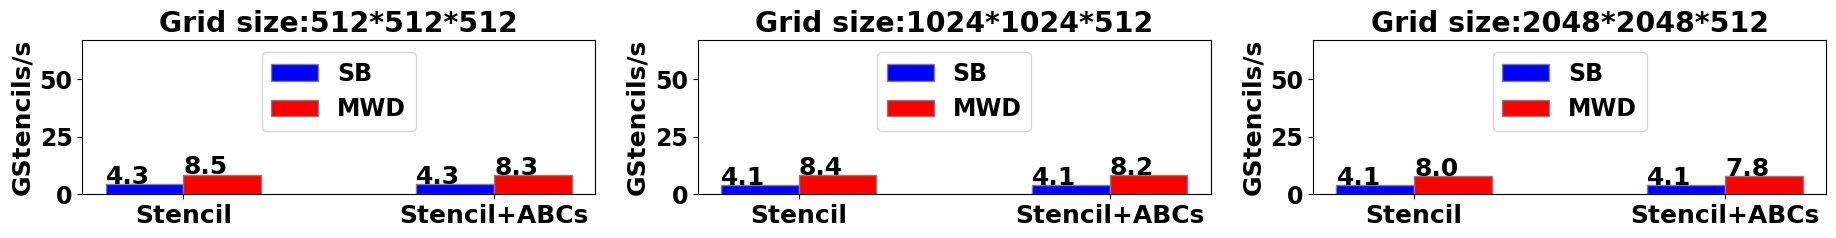

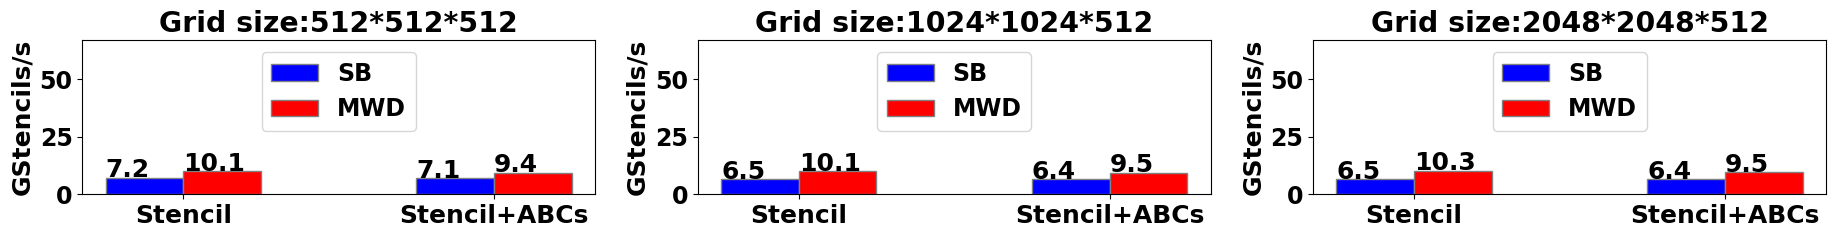

In [25]:
root_folder='./grid_perf/Shaheen_workq2/'
root_folder='./grid_perf/Shaheen_workq_best_compilation_pars_new/'
###################################################################################################################
order='_1st'
save_paths=['../performances/haswell_1st_grids_gflops.pdf',
            '../performances/haswell_1st_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_shaheen+'\n 1st order results',metric='gflops',gflops_limit=3900)

save_paths=['../performances/haswell_1st_grids_gstencils.pdf',
            '../performances/haswell_1st_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_shaheen+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/haswell_2nd_grids_gflops.pdf',
            '../performances/haswell_2nd_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_shaheen+'\n 2nd order results',metric='gflops',gflops_limit=3900)
save_paths=['../performances/haswell_2nd_grids_gstencils.pdf',
            '../performances/haswell_2nd_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_shaheen+'\n 2nd order results',metric='gstencils')
###################################################################################################################


## Plot performance for grids, Kanary

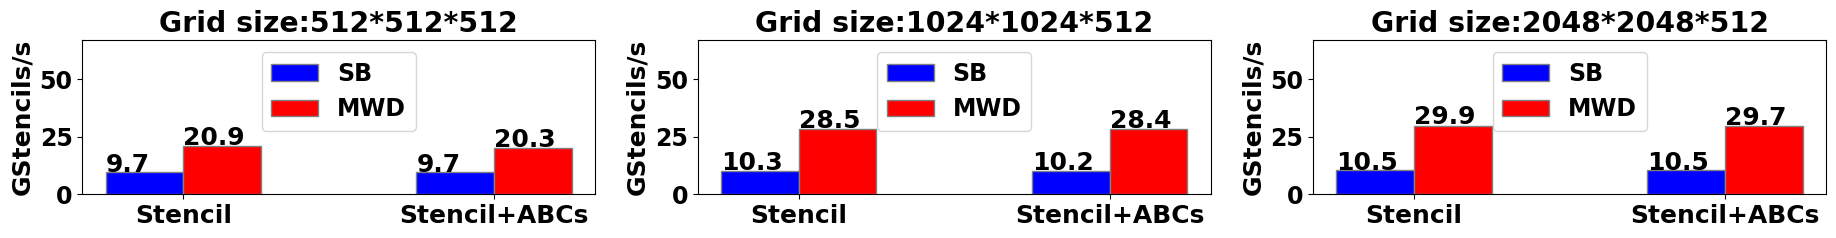

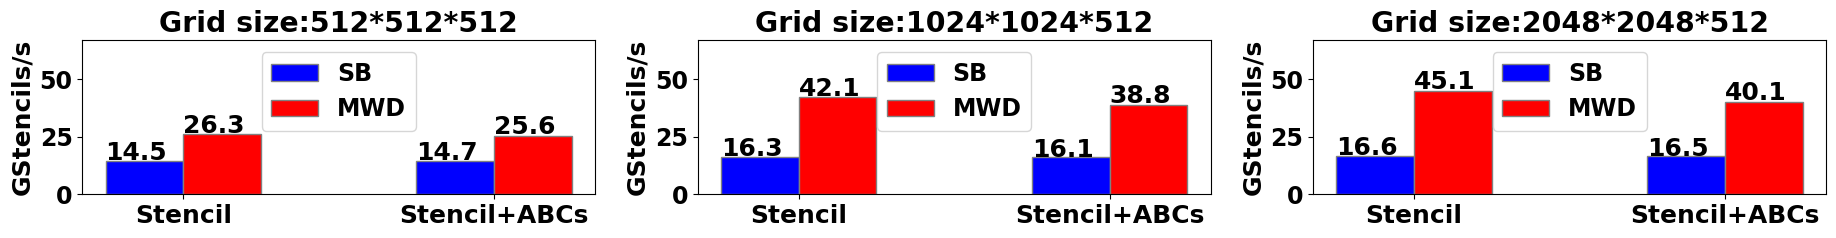

In [26]:
root_folder='./grid_perf/Kanary/'
###################################################################################################################
order='_1st'
save_paths=['../performances/kanary_1st_grids_gflops.pdf',
            '../performances/kanary_1st_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 1st order results',metric='gflops',gflops_limit=3900)

save_paths=['../performances/kanary_1st_grids_gstencils.pdf',
            '../performances/kanary_1st_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/kanary_2nd_grids_gflops.pdf',
            '../performances/kanary_2nd_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 2nd order results',metric='gflops',gflops_limit=3900)
save_paths=['../performances/kanary_2nd_grids_gstencils.pdf',
            '../performances/kanary_2nd_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 2nd order results',metric='gstencils')
###################################################################################################################

## Plot performance for grids, AMD EPYC 7763

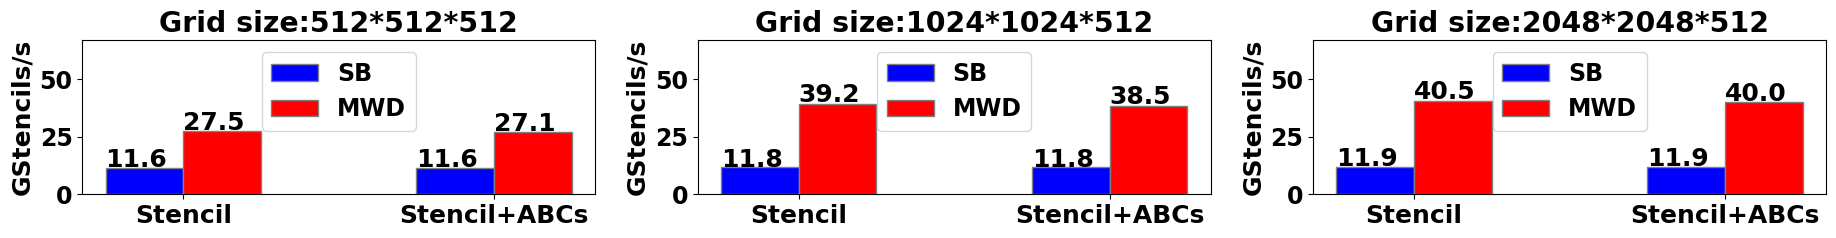

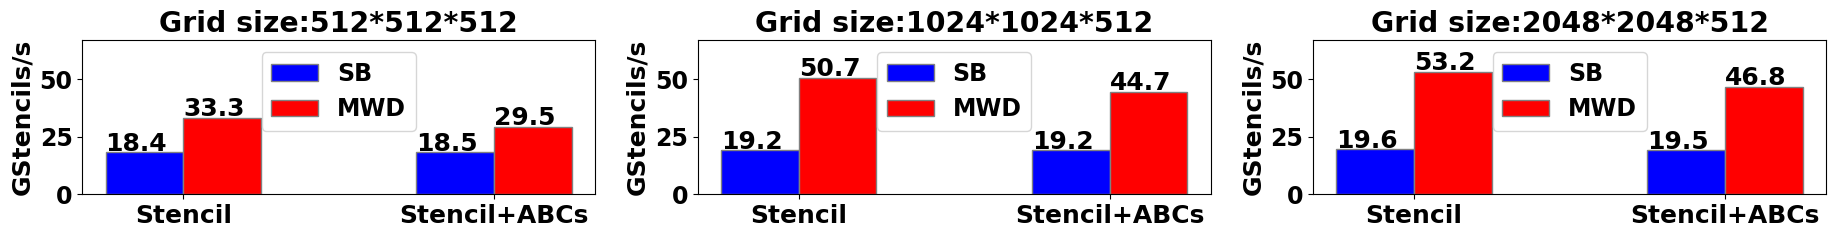

In [27]:
root_folder='./grid_perf/Milan_7763/'
###################################################################################################################
order='_1st'
save_paths=['../performances/Milan_7763_1st_grids_gflops.pdf',
            '../performances/Milan_7763_1st_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 1st order results',metric='gflops',gflops_limit=3900)

save_paths=['../performances/Milan_7763_1st_grids_gstencils.pdf',
            '../performances/Milan_7763_1st_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/Milan_7763_2nd_grids_gflops.pdf',
            '../performances/Milan_7763_2nd_grids_gflops.pdf']
# plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 2nd order results',metric='gflops',gflops_limit=3900)
save_paths=['../performances/Milan_7763_2nd_grids_gstencils.pdf',
            '../performances/Milan_7763_2nd_grids_gstencils.pdf']
plot_perf(save_paths,root_folder,order,grids,title_kanary+'\n 2nd order results',metric='gstencils')
###################################################################################################################

## Plot performance for grids, Milan-X

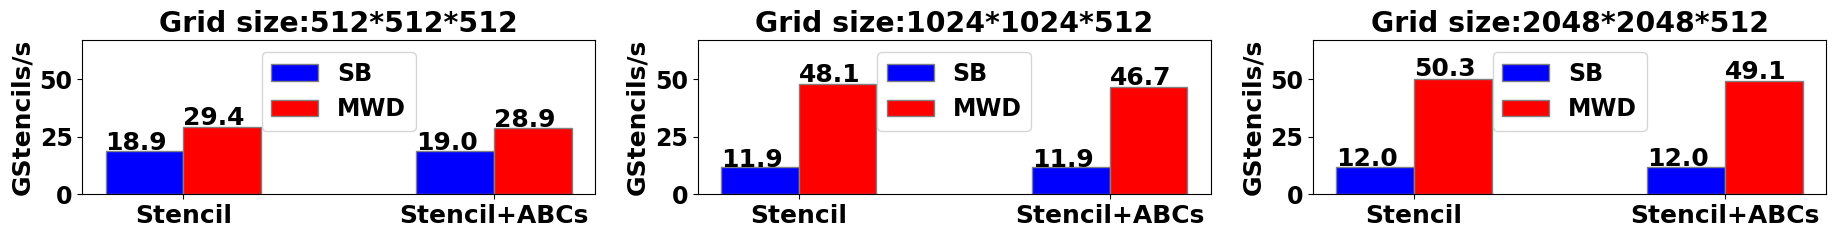

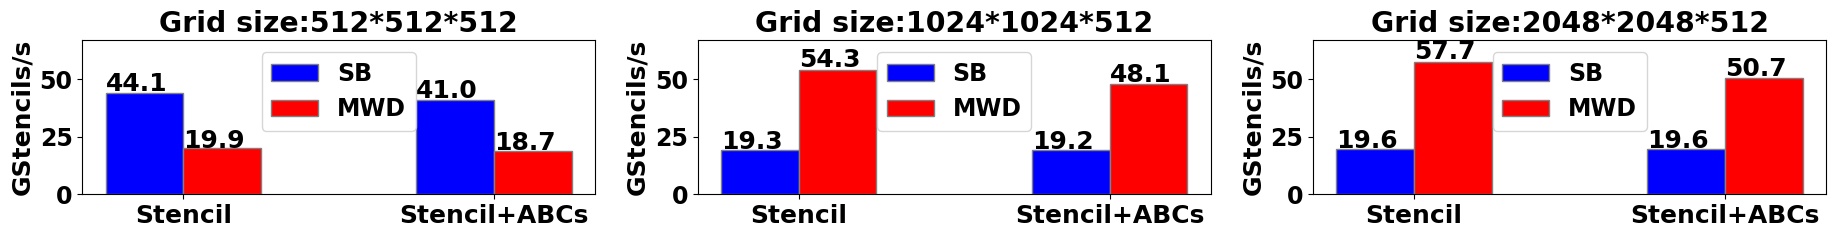

In [28]:
root_folder='./grid_perf/Milan_7773X/'
###################################################################################################################
order='_1st'
save_paths=['../performances/Milan_7773X_1st_grids_gflops.pdf',
            '../performances/Milan_7773X_1st_grids_gflops.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gflops',gflops_limit=3900)

save_paths=['../performances/Milan_7773X_1st_grids_gstencils.pdf',
            '../performances/Milan_7773X_1st_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/Milan_7773X_2nd_grids_gflops.pdf',
            '../performances/Milan_7773X_2nd_grids_gflops.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gflops',gflops_limit=3900)
save_paths=['../performances/Milan_7773X_2nd_grids_gstencils.pdf',
            '../performances/Milan_7773X_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################

## Plot performance for grids, Flamingo

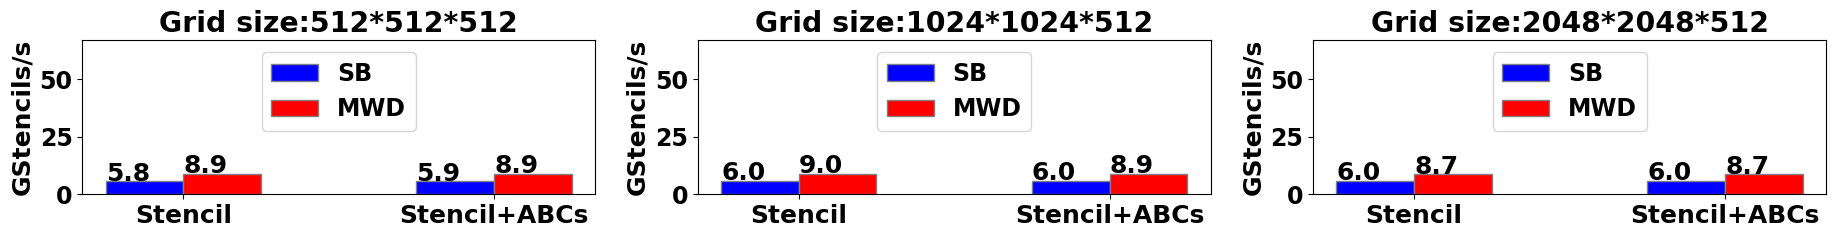

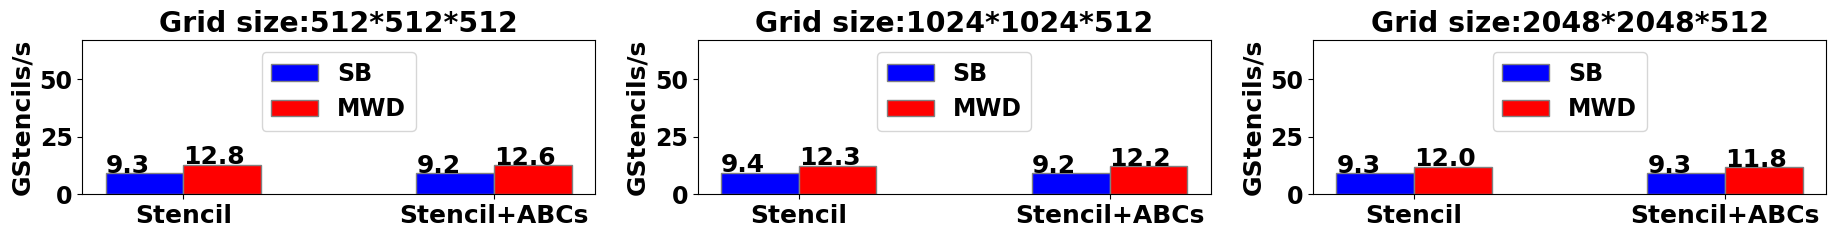

In [29]:
# root_folder='./grid_perf/Flamingo_2/'
root_folder='./grid_perf/Flamingo_best_compilation_pars_new/'
###################################################################################################################
order='_1st'
save_paths=['../performances/flamingo_1st_grids_gflops.pdf',
            '../performances/flamingo_1st_grids_gflops.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gflops',gflops_limit=3900)

save_paths=['../performances/flamingo_1st_grids_gstencils.pdf',
            '../performances/flamingo_1st_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/flamingo_2nd_grids_gflops.pdf',
            '../performances/flamingo_2nd_grids_gflops.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gflops',gflops_limit=3900)
save_paths=['../performances/flamingo_2nd_grids_gstencils.pdf',
            '../performances/flamingo_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
###################################################################################################################

## Plot performance for grids, Sapphire Rapids